#  OncoFlow AI: Tumor Evolution & Treatment Resistance Prediction System

##  Problem Statement
Cancer is a continuously evolving disease where tumors change over time due to mutations. These changes often lead to treatment resistance, making therapies ineffective after an initial response.

There is a need for intelligent systems that can analyze tumor progression over time and predict whether a patient will become resistant to a treatment.

---

##  Objective
To develop a machine learning model that:
- Tracks tumor growth over multiple time points
- Analyzes mutation patterns
- Predicts treatment resistance (Resistant / Sensitive)

---

##  Key Concept
Tumor progression follows:

Mutation Increase → Tumor Growth → Treatment Pressure → Resistance

---

##  Dataset Overview
We simulate longitudinal cancer patient data including:
- Patient_ID
- Time_Point (1,2,3)
- Tumor_Size
- Mutation_Load
- Treatment_Type
- Resistance (Target)

---

## 🔍 Sample DataFrame Preview
| Patient_ID | Time_Point | Tumor_Size | Mutation_Load | Treatment_Type | Resistance |
|------------|-----------|------------|----------------|----------------|------------|
| 0 | 1 | 5 | 3.2 | 1 | 0 |
| 0 | 2 | 6 | 4.1 | 1 | 0 |
| 0 | 3 | 8 | 6.5 | 1 | 1 |

---

## ⚙️ Methodology
1. Generate time-series dataset  
2. Aggregate patient-level features  
3. Train Random Forest model  
4. Predict treatment resistance  
5. Visualize tumor evolution  

---

##  Tools Used
- Python
- Pandas, NumPy
- Scikit-learn
- Matplotlib

---

##  Expected Outcome
- Predict resistance early  
- Help in treatment planning  
- Understand tumor evolution  

---

##  Future Scope
- Use real datasets (TCGA)
- Apply Deep Learning (LSTM)
- Build clinical dashboard

/tmp/ipykernel_3335/1047620961.py:38: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  resistance = df.groupby("Patient_ID").apply(resistance_logic).reset_index()



📊 Dataset Preview:

   Patient_ID  Time_Point  Tumor_Size  Mutation_Load  Treatment_Type  \
0           0           1           7       7.072386               1   
1           0           2           4       1.525390               1   
2           0           3           8       5.762884               1   
3           1           1           5       6.067150               1   
4           1           2           7       4.241307               0   

   Resistance  
0           0  
1           0  
2           0  
3           0  
4           0  

🎯 Accuracy: 0.85

📋 Classification Report:
               precision    recall  f1-score   support

         0.0       0.88      0.96      0.92        52
         1.0       0.33      0.12      0.18         8

    accuracy                           0.85        60
   macro avg       0.61      0.54      0.55        60
weighted avg       0.80      0.85      0.82        60



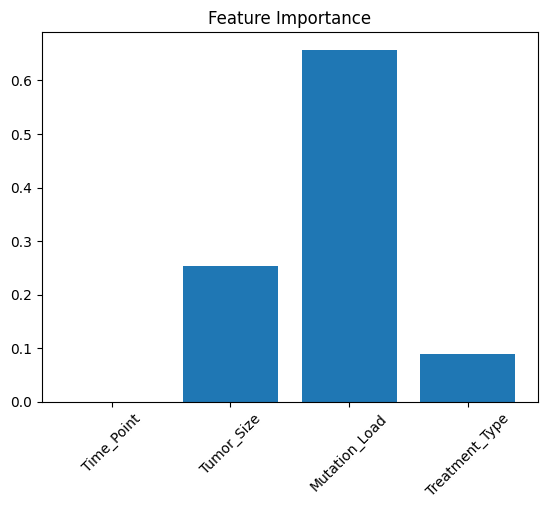

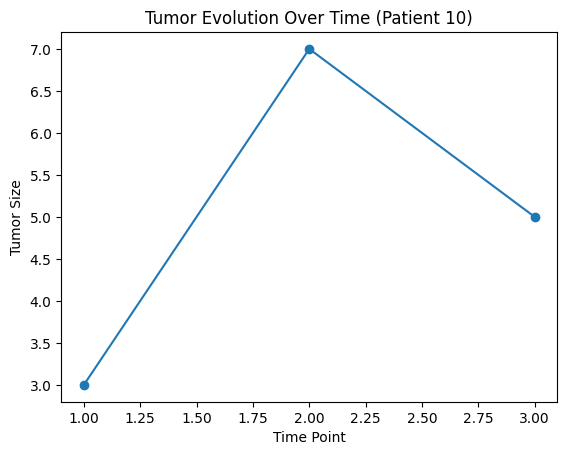


🧪 New Patient Result: Sensitive


In [1]:
# =========================================
# 🧬 OncoFlow AI - Full Project Code
# =========================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

np.random.seed(42)

# 2. Create Dataset (Time-Series Cancer Data)
n_patients = 300

data = {
    "Patient_ID": np.repeat(np.arange(n_patients), 3),
    "Time_Point": np.tile([1, 2, 3], n_patients),
    "Tumor_Size": np.random.randint(1, 10, n_patients * 3),
    "Mutation_Load": np.random.rand(n_patients * 3) * 10,
    "Treatment_Type": np.random.choice([0, 1], n_patients * 3)  # 0=Chemo, 1=Targeted
}

df = pd.DataFrame(data)

# 3. Create Target Variable (Resistance)
def resistance_logic(group):
    growth = group["Tumor_Size"].diff().sum()
    mutation = group["Mutation_Load"].mean()

    if growth > 3 and mutation > 5:
        return 1  # Resistant
    else:
        return 0  # Sensitive

resistance = df.groupby("Patient_ID").apply(resistance_logic).reset_index()
resistance.columns = ["Patient_ID", "Resistance"]

# Merge target back
df = df.merge(resistance, on="Patient_ID")

# 4. Show Dataset
print("\n📊 Dataset Preview:\n")
print(df.head())

# 5. Aggregate Data (Patient Level)
agg_df = df.groupby("Patient_ID").mean().reset_index()

X = agg_df.drop(["Patient_ID", "Resistance"], axis=1)
y = agg_df["Resistance"]

# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Train Model
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# 8. Predictions
y_pred = model.predict(X_test)

# 9. Evaluation
print("\n🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📋 Classification Report:\n", classification_report(y_test, y_pred))

# 10. Feature Importance Plot
importance = model.feature_importances_
features = X.columns

plt.figure()
plt.bar(features, importance)
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# 11. Tumor Evolution Visualization (Sample Patient)
sample_patient = df[df["Patient_ID"] == 10]

plt.figure()
plt.plot(sample_patient["Time_Point"], sample_patient["Tumor_Size"], marker='o')
plt.title("Tumor Evolution Over Time (Patient 10)")
plt.xlabel("Time Point")
plt.ylabel("Tumor Size")
plt.show()

# 12. New Patient Prediction
new_patient = pd.DataFrame({
    "Time_Point": [1,2,3],
    "Tumor_Size": [4,7,9],
    "Mutation_Load": [2.5,5.5,8.0],
    "Treatment_Type": [1,1,1]
})

new_patient_agg = new_patient.mean().to_frame().T
prediction = model.predict(new_patient_agg)

print("\n New Patient Result:",
      "Resistant" if prediction[0] == 1 else "Sensitive")